# K най-близки съседи и регуляризация

Целите днес:

* Да се запознаем с алгоритъма K най-близки съседи (kNN)
* Да задълбочим интуицията си около термините underfit, overfit, регурализация
* Да начертаем няколко графики на matplotlib
* Увод в "масажирането на данни" (data munging, data wrangling) 

In [46]:
# !pip install eli5

In [ ]:
import numpy as np
import mglearn
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
import eli5.sklearn
import warnings

from sklearn.neighbors import KNeighborsClassifier
from sklearn.datasets import make_moons, load_breast_cancer
from sklearn.linear_model import LinearRegression, Lasso, Ridge, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier

warnings.filterwarnings(action='ignore', module='scipy', message='^internal gelsd')

%matplotlib inline

# Overfit, underfit и генерализация

Обикновено ни интересува колко добре се справя един модел с нови данни, които не е виждал. Тъй като нямаме добър начин да измерим това (освен да го пуснем в продукция за няколко месаца и да видим), използваме друг подход – разделяме данните на тренировъчни и тестови, тренираме модела с тренировъчните и проверяваме колко добре се справя върху тестовите. Ползваме тестовите данни като proxy метрика за генерализацията.

Ако модела не се справя оптимално, обикновено говорим за две неща:

* Underfitting – модела не се справя добре нито на тестовите, нито на тренировъчните. Това значи, че не е научил достатъчно от сигнала в данните.
* Overfitting – модела се справя добре на тренировъчните данни, но зле на тестовите. Това значи, че е научил част от шума в тренировъчните данни, който (естествено) е различен в тестовите.

# Прости и сложни модели

Често си ще говорим са "сложност" на моделите:

* "Сложността" е условно понятие, което определя колко добре се справя един алгоритъм с комплексни зависимостти в данните.
* Линейната регресия е "по-прост" модел, понеже може да открие само линейни зависимости. Support vector machines, decision trees и невронни мрежи са по-сложни модели, които могат да откриват по-сложни (нелинейни) зависимости.
* По-сложните алгоритми са склонни да научат шума в дадени данни (overfit).
* По-простите алгоритми са склонни да пропуснат сложни зависимости в данните (underfit).
* Повечето алгоритми имат параметър, с който може да ги караме да се държат като по-прости. Това се нарича регуларизация. Всеки алгоритъм има различна форма на регуляризация.

# k-Nearest Neighbours

В `scikit-learn` методите, базирани на съседство, са имплементирани в модула [sklearn.neighbors](https://scikit-learn.org/stable/modules/classes.html#module-sklearn.neighbors). Класификационния алгоритъм kNN e имплементиран в класа [KNeighborsClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html#sklearn.neighbors.KNeighborsClassifier).

Характеристики:

* Има един параметър $k$, който е цяло число
* Запазва всички тренировъчни данни
* Когато трябва да предвижда класа на нова точка, намира $k$-те най-близки точки (евклидово) в тренировъчните данни и отговаря с този клас, който е преобладаващ
* За да го държим просто – в случай на равенство, винаги отговаря с константен клас
* Може да се използват и други метрики
* При добавяне на тегла (`weights=‘distance’`) тежестта на гласа на всеки съсед е пропорционална на дистанцията му от примера.

## Метрики за разстояние (distance metrics) 

kNN, както и някои други алгоритми (напр. kMeans) работят чрез изличсляване на близост между два примера (точки в n-мерното пространство). Разстояние между точки в n-мерното пространство може да се изчислява по различни начини, като най-популярния е семейството от метрики Минковски (Minkowski distance).       

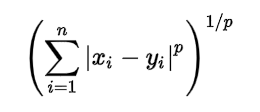      
При p=1 тази метрика отговаря на "манхатънско разстояние" (manhattan distance), а при p=2 - на Евклидово разстояние (Еuclidean distances).  

Манхатънско растояние: 
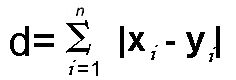       

Пример:       
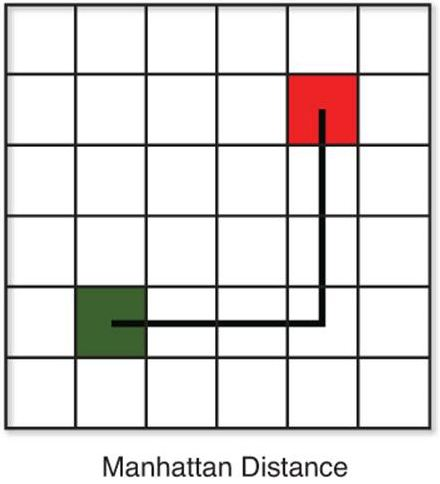

Eвклидово разстоятие:     
    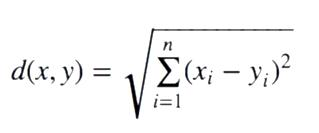
    
Пример: 
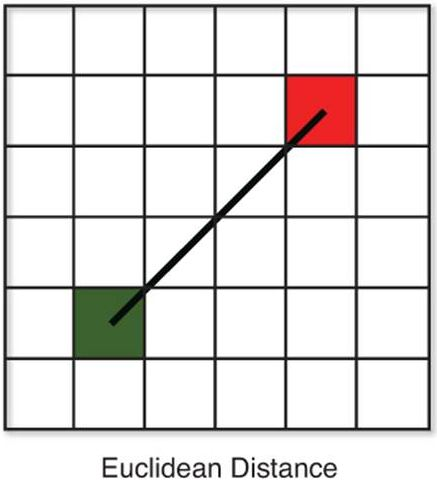

Повече за различните метрики можете да прочетете [тук](https://www.kdnuggets.com/2020/11/most-popular-distance-metrics-knn.html). Достъпните за kNN метрики в scikit-learn са на [sklearn.metrics.pairwise.distance_metrics](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.pairwise.distance_metrics.html#sklearn.metrics.pairwise.distance_metrics).

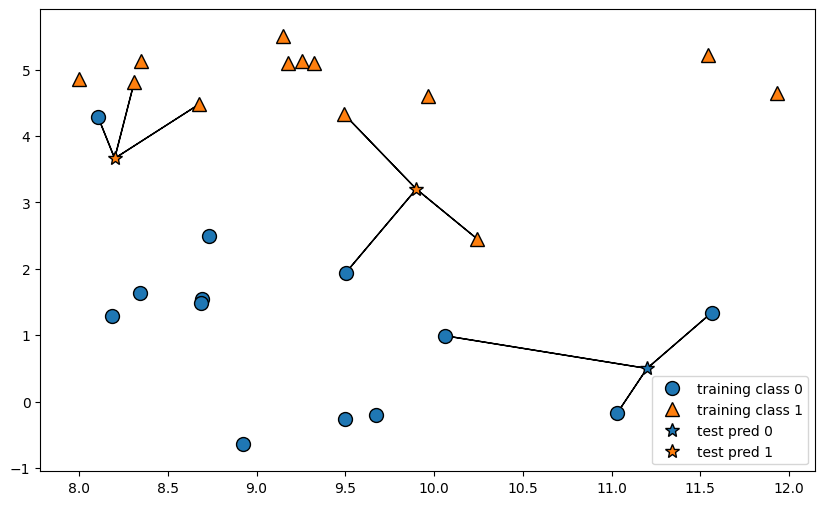

In [48]:
plt.figure(figsize=(10, 6))
mglearn.plot_knn_classification.plot_knn_classification(n_neighbors=3)

# k и регуларизация

Параметърът $k$ се явява форма на регуляризация. Колкото по-висок е, толкова "по-прост" ще бъде моделът (ще открие по-проста зависимост между данните).

In [49]:
def plot_knn_parameter():
    X, y = mglearn.datasets.make_forge()

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    for n_neighbors, ax in zip([1, 3, 9], axes):
        clf = KNeighborsClassifier(n_neighbors=n_neighbors).fit(X, y)
        mglearn.plots.plot_2d_separator(clf, X, fill=True, eps=0.5, ax=ax, alpha=.4)
        mglearn.discrete_scatter(X[:, 0], X[:, 1], y, ax=ax)
        ax.set_title("{} neighbour(s)".format(n_neighbors))

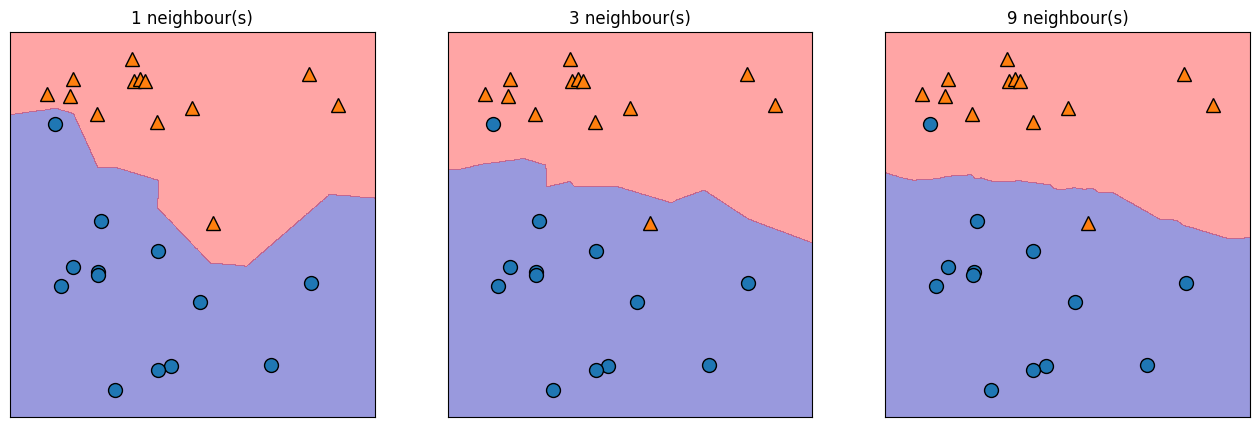

In [50]:
plot_knn_parameter()

## Пример с различен k

* Представете си, че имаме град, разделен от река.
* Хората от двете страни на реката са склонни да имат различни политически ориентации – едните са червени, другите са сини.
* Това съответсвие не е едно към едно – някои червени хора са се преместили от синята страна на реката, някои хора родени в синята страна са станали червени по лични причини.
* Ще се опитаме да предвидим политическата ориентация на хората на база координатите на които живеят. Няма да имаме 100% успеваемост, тъй като координатите на жилището не са достатъчна информация да предвидим точно.
* Ще си създадем множество от данни с функцияна `make_moons`, с което да моделираме този казус.

`make_moons` създава два полумесеца, вложени един в друг.

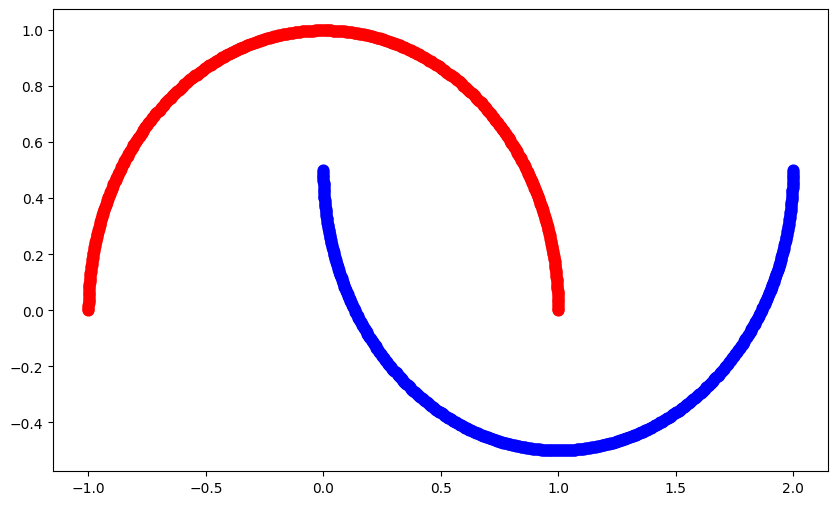

In [51]:
X, y = make_moons(1000, noise=0, random_state=0)
red = X[y == 0]
blue = X[y == 1]
plt.figure(figsize=(10, 6))
plt.scatter(red[:, 0],  red[:, 1],  color='red', alpha=1, s=60)
plt.scatter(blue[:, 0], blue[:, 1], color='blue', alpha=1, s=60);

Може да си представите как реката минава между тях.

`make_moons` има параметър `noise`, който въвежда шум. Например:

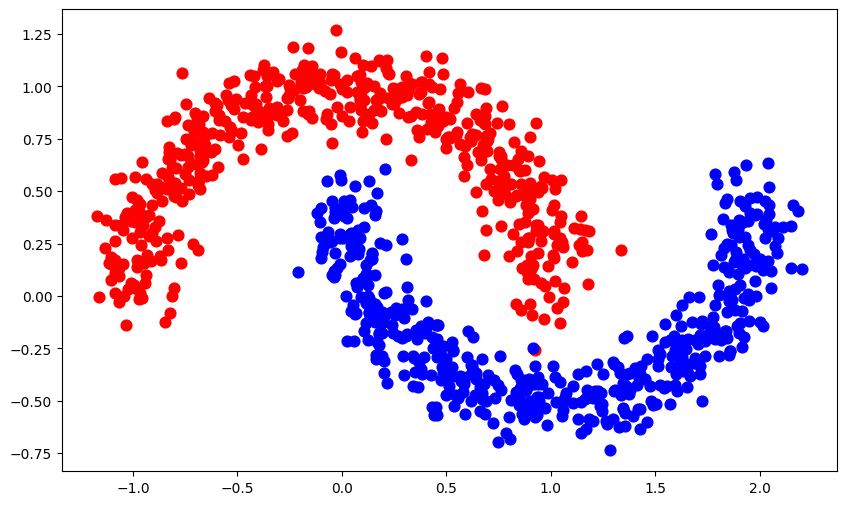

In [52]:
X, y = make_moons(1000, noise=0.1, random_state=0)
red = X[y == 0]
blue = X[y == 1]
plt.figure(figsize=(10, 6))
plt.scatter(red[:, 0],  red[:, 1],  color='red', alpha=1, s=60)
plt.scatter(blue[:, 0], blue[:, 1], color='blue', alpha=1, s=60);

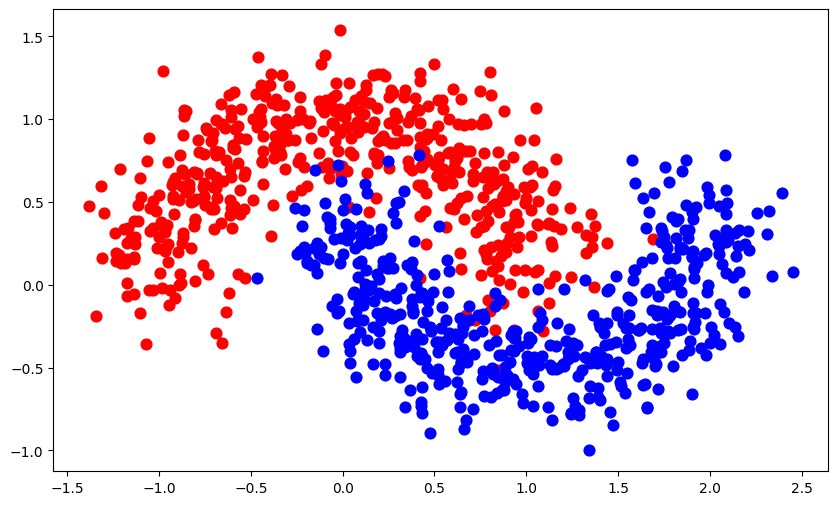

In [53]:
X, y = make_moons(1000, noise=0.2, random_state=0)
red = X[y == 0]
blue = X[y == 1]
plt.figure(figsize=(10, 6))
plt.scatter(red[:, 0],  red[:, 1],  color='red', alpha=1, s=60)
plt.scatter(blue[:, 0], blue[:, 1], color='blue', alpha=1, s=60);

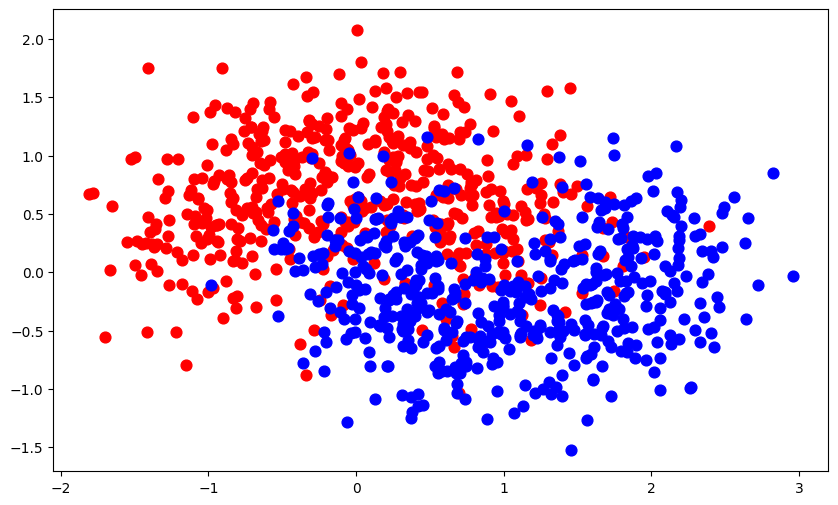

In [54]:
X, y = make_moons(1000, noise=0.4, random_state=0)
red = X[y == 0]
blue = X[y == 1]
plt.figure(figsize=(10, 6))
plt.scatter(red[:, 0],  red[:, 1],  color='red', alpha=1, s=60)
plt.scatter(blue[:, 0], blue[:, 1], color='blue', alpha=1, s=60);

Ще ползваме такъв шум 0.4 за нашия пример.

Нека си създадем множество от данни начисто и да го разделим на тренировъчно и тестово множество.

In [55]:
X, y = make_moons(1500, noise=0.4, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

Да видим как изглежда отново:

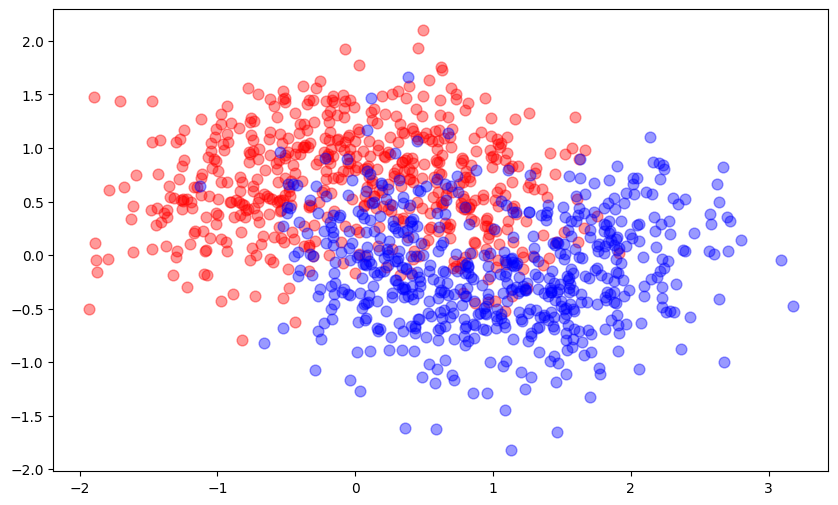

In [56]:
red = X_train[y_train == 0]
blue = X_train[y_train == 1]
plt.figure(figsize=(10, 6))
plt.scatter(red[:, 0],  red[:, 1],  color='red', alpha=0.4, s=60)
plt.scatter(blue[:, 0], blue[:, 1], color='blue', alpha=0.4, s=60);

Нека да видим как се държи kNN с няколко различни стойности за k:

In [57]:
for k in [1, 7, 21, 501]:
    clf = KNeighborsClassifier(n_neighbors=k)
    clf.fit(X_train, y_train)
    
    train_score = clf.score(X_train, y_train)
    test_score  = clf.score(X_test, y_test)
    
    print("k = {:3}, train score = {:1.5f}, test score = {:1.5f}".format(k, train_score, test_score))

k =   1, train score = 1.00000, test score = 0.76800
k =   7, train score = 0.88444, test score = 0.82933
k =  21, train score = 0.87733, test score = 0.84533
k = 501, train score = 0.82844, test score = 0.81600


Нека всъщност начертаем графика. Ще ползваме следната функция:

In [58]:
def plot_knn_scores(ks):
    train_scores = []
    test_scores = []
    
    for k in ks:
        clf = KNeighborsClassifier(n_neighbors=k).fit(X_train, y_train)
        train_score = clf.score(X_train, y_train)
        test_score = clf.score(X_test, y_test)
        
        train_scores.append(train_score)
        test_scores.append(test_score)

    plt.figure(figsize=(10, 6))
    plt.plot(ks, train_scores, color='blue', label='train score')
    plt.plot(ks, test_scores, color='green', label='test score')
    plt.legend()

Така изглеждат нещата за $k \in [1, 10)$:

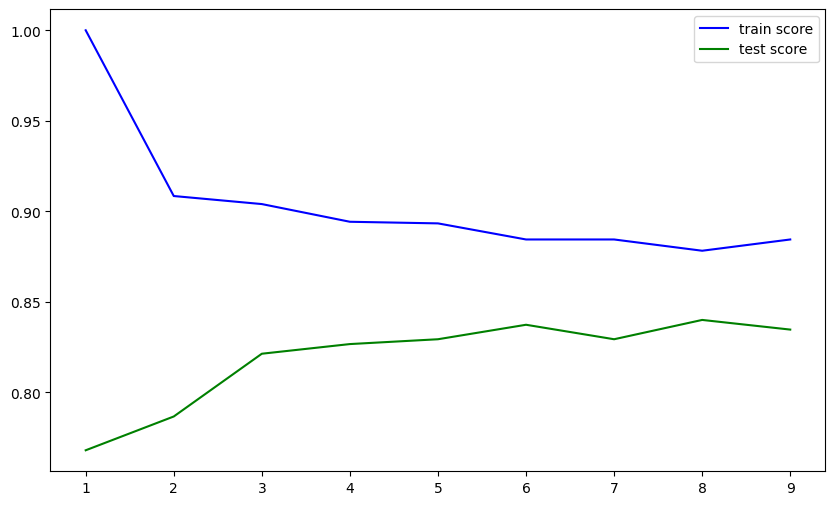

In [59]:
plot_knn_scores(range(1, 10))

Нека да видим $k \in [1, 100)$:

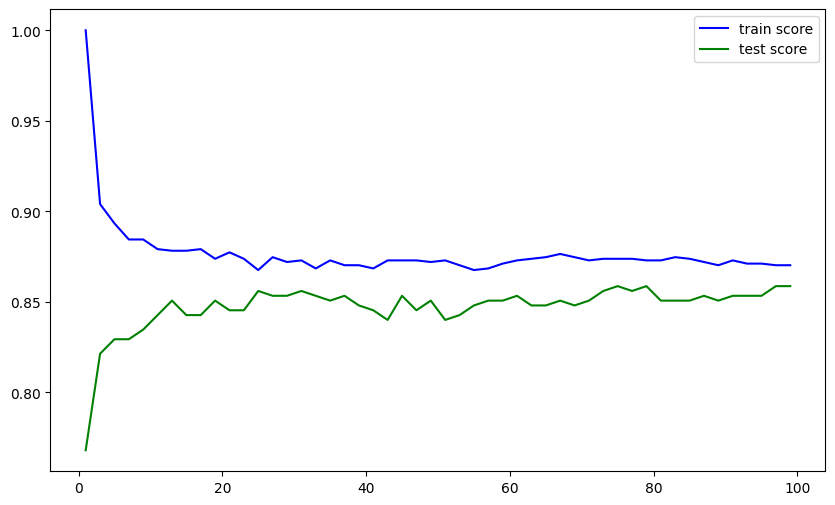

In [60]:
plot_knn_scores(range(1, 100, 2))

И финално, $k \in [1, 1130)$:

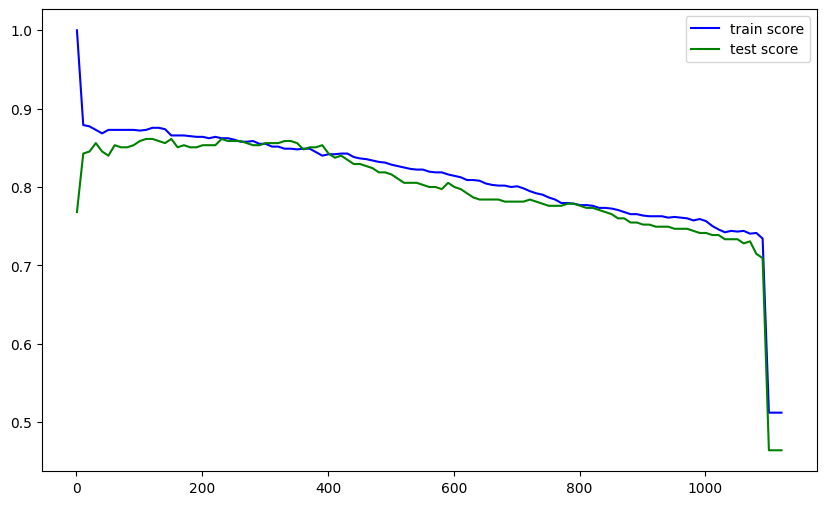

In [61]:
plot_knn_scores(range(1, 1130, 10))

Тук виждаме следните неща:

* С опростяването на модела, оценката над пренировъчните данни (train score) намалява (почти монотонно). 
* Най-сложният модел има ниска тестова оценка (test score). С опростяването на модела, тестовата оценка започва да расте, но от един момент нататък започва да намалява.

От графиката може да видим, че при $k = 1$ има overfitting, докато при по-големи $k$ ($k > 400$) започва да има underfitting.

Търсим някакъв $k$, който да има оптимален train score (например $k = 351$ се приближава).

Друг начин да осмислим резултата е като начертаем "граница на решението" (decision boundary). За да стане това, просто оцветяваме всяка точка от картата с цвета, който класификатора ще предвиди.

За целта ползваме следните функции:

In [85]:
def plot_decision_boundary(classifier, alpha=1):
    plt.figure(figsize=(10, 6))
    eps = X.std() / 2.
    ax = plt.gca()

    x_min, x_max = X[:, 0].min() - eps, X[:, 0].max() + eps
    y_min, y_max = X[:, 1].min() - eps, X[:, 1].max() + eps
    xx = np.linspace(x_min, x_max, 700)
    yy = np.linspace(y_min, y_max, 700)

    X1, X2 = np.meshgrid(xx, yy)
    X_grid = np.c_[X1.ravel(), X2.ravel()]
    
    cmap = matplotlib.colors.ListedColormap(['red', 'blue'])
    decision_values = classifier.predict(X_grid)
    ax.imshow(decision_values.reshape(X1.shape), extent=(x_min, x_max, y_min, y_max),
              aspect='auto', origin='lower', alpha=alpha, cmap=cmap)
    
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_xticks(())
    ax.set_yticks(())

In [63]:
def summarize_knn(k):
    classifier = KNeighborsClassifier(n_neighbors=k)
    classifier.fit(X_train, y_train)
    print("K = {}".format(k))
    print("train score: {}".format(classifier.score(X_train, y_train)))
    print("test score:  {}".format(classifier.score(X_test, y_test)))
    plot_decision_boundary(classifier)

Ето как изглеждат нещата при $k = 1$.

K = 1
train score: 1.0
test score:  0.768


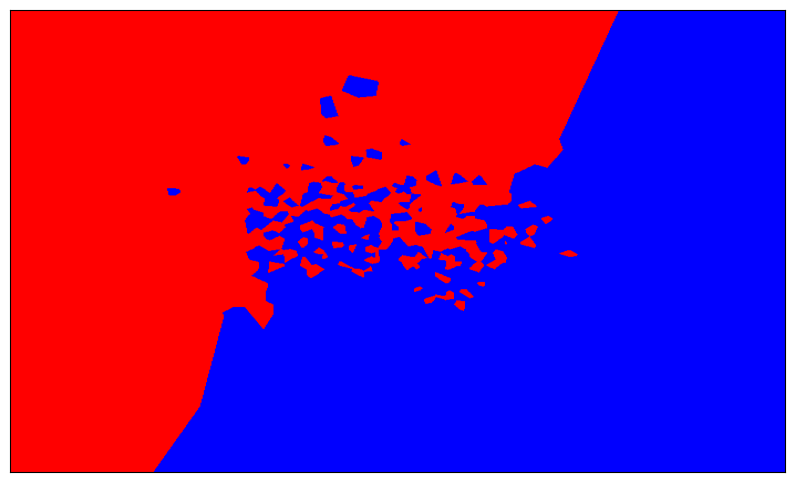

In [64]:
summarize_knn(1)

Тук виждаме доста научен шум и малко острови.

Увеличавайки $k$, научения шум намалява и островите стават по-малки:

K = 3
train score: 0.904
test score:  0.8213333333333334


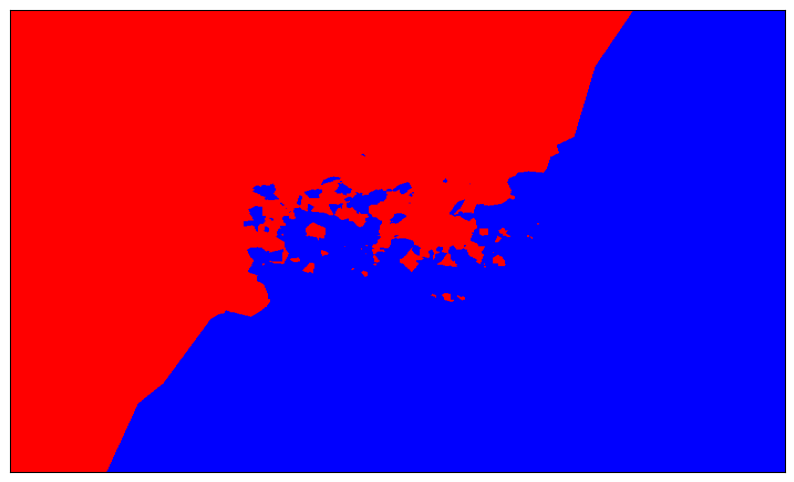

In [65]:
summarize_knn(3)

K = 9
train score: 0.8844444444444445
test score:  0.8346666666666667


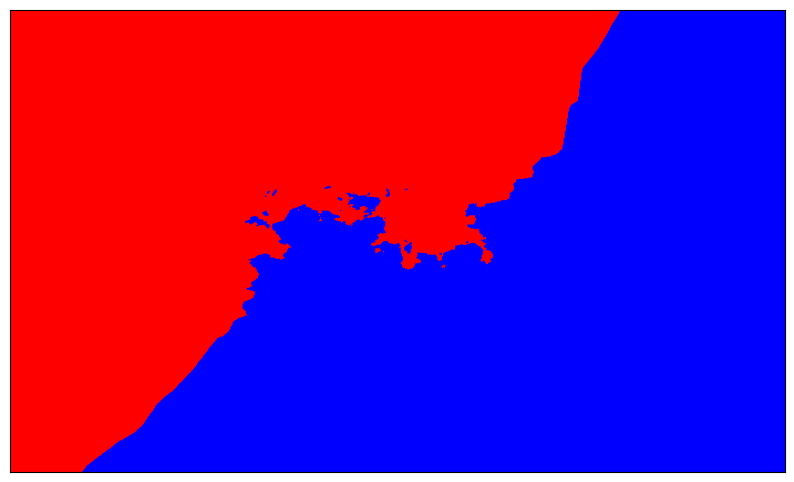

In [66]:
summarize_knn(9)

K = 57
train score: 0.8684444444444445
test score:  0.8506666666666667


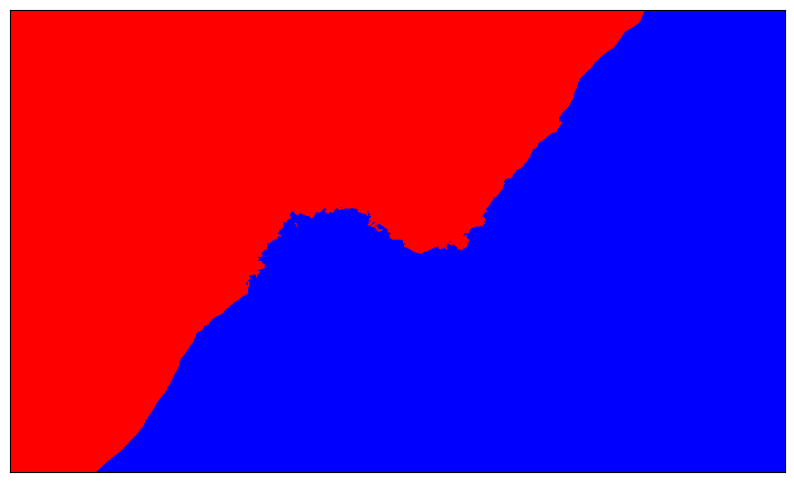

In [67]:
summarize_knn(57)

При $k = 151$ започваме да виждаме очакваните резултати:

K = 151
train score: 0.8657777777777778
test score:  0.8613333333333333


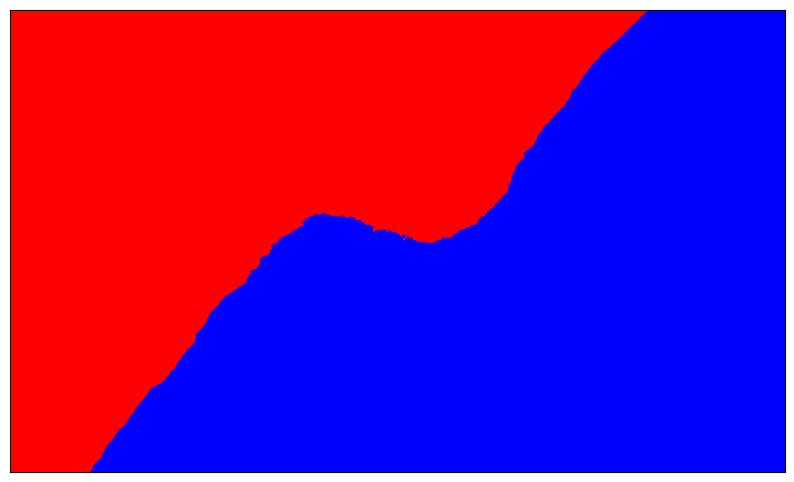

In [68]:
summarize_knn(151)

Ако прекалим обаче, моделът не научава добре границата:

K = 501
train score: 0.8284444444444444
test score:  0.816


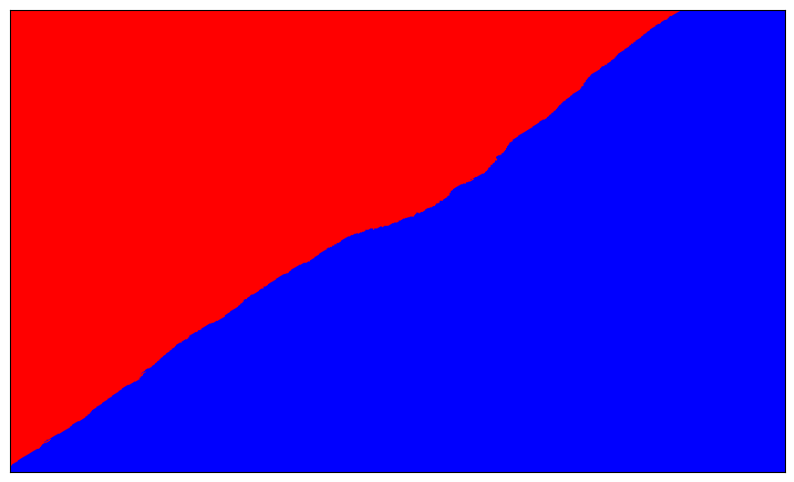

In [69]:
summarize_knn(501)

Може и да начертаем как се променят оценките над тестовото и тренировъчното множество при промяна на размера на входните данни ($n$).

In [70]:
def plot_knn_with_different_datasets():
    percentages = range(10, 100, 1)
    test_scores = []
    train_scores = []
    for percent in percentages:
        size = int(len(X_train) * ((percent + 1) / 100.0))
        X_subset = X_train[:size, :]
        y_subset = y_train[:size]
        
        clf = KNeighborsClassifier(n_neighbors=123)
        clf.fit(X_subset, y_subset)
        
        train_score = clf.score(X_subset, y_subset)
        test_score = clf.score(X_test, y_test)
        
        train_scores.append(train_score)
        test_scores.append(test_score)
        
    plt.figure(figsize=(10, 6))
    plt.plot(percentages, train_scores, color='blue', label='train score')
    plt.plot(percentages, test_scores, color='green', label='test score')
    plt.legend()

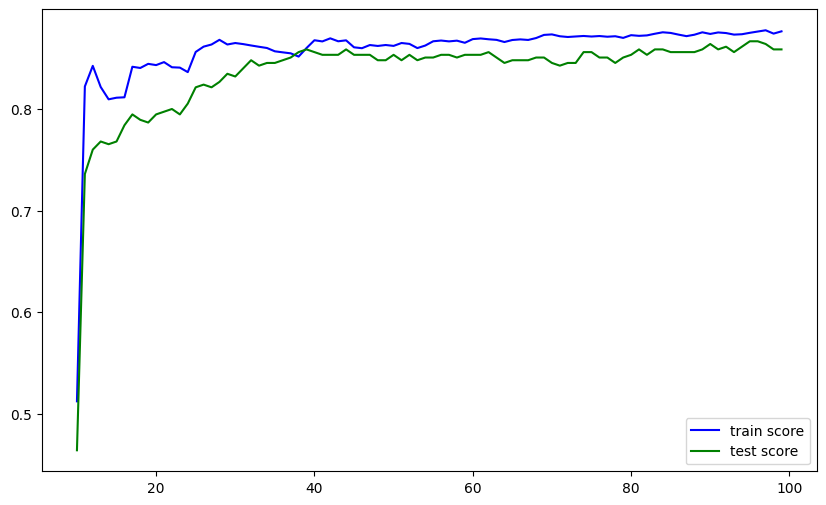

In [71]:
plot_knn_with_different_datasets()

Виждаме, че колкото повече данни имаме, толкова по-добри оценки получаваме. 

Един извод, който може да си извадите, е че колкото повече данни имаме, толкова по-малко склонен е алгоритъма към overfitting. 
(Но в реалността това зависи и от разпределението на данните.)

## kNN и регресия 

kNN може да се използва и за регресия. В scikit-learn това е имплементирано в класа [KNeighborsRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsRegressor.html).      


Разликата е, че вместо да се взима най-често срещаният клас на най-близките съседи, се осреднява числовата стойност на целевата им променлива.

## Задачи върху kNN: 
* Изберете едно от примерните множества с данни за класификация и го разделете на тренировъчно и тестово множество. 
* Изпробвайте различни стойности на k и различни метрики. 
* Начертайте графики за промяната на тренировъчните и тестовите оценки и за границата на решението (NB: при повече класове функцията `plot_decision_boundary()` трябва да се модифицира за съответния брой класове.)

# Линейна регресия - втора част

Нека да разгледаме множеството от данни California housing и да се опитаме да приложим линейна регресия с различни видове регуларизация.

Първо, нека да погледнем данните:

In [3]:
from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing()

Ще отворим данните през `pandas`, за да ги разглеждаме по-лесно.

In [4]:
frame = pd.DataFrame(housing.data, columns=housing.feature_names)
frame.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [5]:
frame.shape

(20640, 8)

Да видим какво са отделните колони:

In [6]:
print(housing.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

Нека пробваме да натренираме проста линейна регресия:

In [7]:
housing.target[:10]

array([4.526, 3.585, 3.521, 3.413, 3.422, 2.697, 2.992, 2.414, 2.267,
       2.611])

In [46]:
X, y = housing.data, housing.target
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)

print("train score:", model.score(X_train, y_train))
print("test score: ", model.score(X_test, y_test))

train score: 0.609873031052925
test score:  0.5910509795491351


Тук изглежда, че нямаме пренагаждане. Но пък може би ще успеем да постигнем резултат ако помасажираме входните данни.

## Подготовка (или "масажиране") на данни 

В машиннното самообучение почти никога не използваме данните в суров вид. Напротив, обикновено те преминават през някаква предварителна обработка - за премахване на липсващите стойности, преобразуване към числови стойности, скалиране, избиране на характеристики (feature selection). 

В skitilearn подобни манипулации се правят чрез класовете и методите от модула [sklearn.preprocessing](https://scikit-learn.org/stable/modules/classes.html#module-sklearn.preprocessing). 

Днес ще разгледаме някои методи за подготовка на данни и ще продължим с тази тема следващите пъти. 

In [47]:
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, MinMaxScaler

Нека разгледаме данните:

In [48]:
frame.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
count,2.064e+04,2.064e+04,2.064e+04,2.064e+04,2.064e+04,2.064e+04,2.064e+04,2.064e+04
mean,3.8707,28.639,5.429,1.0967,1425.5,3.0707,35.632,-119.57
std,1.8998,12.586,2.4742,0.47391,1132.5,10.386,2.136,2.0035
min,0.4999,1.0,0.84615,0.33333,3.0,0.69231,32.54,-124.35
25%,2.5634,18.0,4.4407,1.0061,787.0,2.4297,33.93,-121.8
50%,3.5348,29.0,5.2291,1.0488,1166.0,2.8181,34.26,-118.49
75%,4.7432,37.0,6.0524,1.0995,1725.0,3.2823,37.71,-118.01
max,15.0,52.0,141.91,34.067,3.5682e+04,1243.3,41.95,-114.31


In [49]:
housing.target

array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894], shape=(20640,))

Имаме само 8 колони за 20 640 реда данни - можем да се опитаме да увеличим синтетично данните. Също така, виждаме, че диапазона на стойностите съществено варира в различните колони. 

## Полиномни характеристики

Един подход, който често дава добри резултати е да добавим степени на характеристиките. Например, ако имаме две характеристики – $x_1$ и $x_2$, да добавим и $x_1^2$, $x_1 x_2$ и $x_2^2$ като нови характеристики.

В scikit learn има клас, който може да направи това:

In [50]:
polynomial = PolynomialFeatures(degree=2, include_bias=True, interaction_only=False)
data = np.array([[2.0, 5.0],
                 [3.0, 4.0]])
polynomial.fit_transform(data)

array([[ 1.,  2.,  5.,  4., 10., 25.],
       [ 1.,  3.,  4.,  9., 12., 16.]])

Друга обработка на данните, която ще направим, е скалиране. Скалирането се прави, за да не се изкривяват коефициентите на регресията от хараксеристики, които имат твърде големи стойности.     

За целта имаме `StandardScaler()`, който изважда средно аритметичното и дели на стандартното отклонение, така че да центрира данните около нулата:

In [51]:
frame[['Population']].describe()

,Population
count,2.064e+04
mean,1425.5
std,1132.5
min,3.0
25%,787.0
50%,1166.0
75%,1725.0
max,3.5682e+04


In [52]:
pd.options.display.float_format = '{:.5}'.format

In [53]:
transformed = StandardScaler().fit_transform(frame[['Population']])
pd.DataFrame(transformed).describe()

,0
count,2.064e+04
mean,-1.1016e-17
std,1.0
min,-1.2561
25%,-0.56381
50%,-0.22913
75%,0.26449
max,30.25


По-често използваният в практиката е [`MinMaxScaler()`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MinMaxScaler.html#sklearn.preprocessing.MinMaxScaler), който скалира данните до определен интервал (по подразбиране [0,1]):

In [54]:
transformed2 = MinMaxScaler().fit_transform(frame[['Population']])
pd.DataFrame(transformed2).describe()

,0
count,2.064e+04
mean,0.039869
std,0.03174
min,0.0
25%,0.021974
50%,0.032596
75%,0.048264
max,1.0


Ще прекараме оригиналните данни през тези трансформации:

In [55]:
data = housing.data
data = StandardScaler().fit_transform(data)
data = PolynomialFeatures(degree=2, include_bias=False).fit_transform(data)

Да видим формата на оригиналните данни и на трансформираните:

In [56]:
print("Original data shape:   ", housing.data.shape)
print("Transformed data shape:", data.shape)

Original data shape:    (20640, 8)
Transformed data shape: (20640, 44)


Нека си разделим данните на тренировъчни и тестови:

In [57]:
X, y = data, housing.target
X_train, X_test, y_train, y_test = train_test_split(data, housing.target, random_state=0)

Преди да тренираме модел, нека си припомним трите вида линейна регресия:

* `LinearRegression` – най-простата възможна, без регуляризация.
* `Ridge` – вариант с L2 регуляризация, която кара всички коефициенти да се опитват да бъдат малки
* `Lasso` – вариант с L1 регуларизация, която кара някои коефициенти да бъдат точно 0

Нека първо да пробваме с `Ridge`:

In [58]:
model = Ridge().fit(X_train, y_train)
train_score = model.score(X_train, y_train)
test_score = model.score(X_test, y_test)

print("train:", train_score)
print("test: ", test_score)

train: 0.6859212853556288
test:  -0.5309461106073339


Тук има стабилен overfit.

Регуляризацията се контролира с един параметър `alpha`. Колкото е по-голям, толкова по-силна е регуляризацията (т.е. модела се опитва да е по-прост). Нека да начертаем train и test score при различни стойности на `alpha`.

In [59]:
def plot_ridge_alpha():
    alphas = np.linspace(0.00001, 200, 100)
    train_scores = []
    test_scores = []
    for alpha in alphas:
        model = Ridge(alpha=alpha).fit(X_train, y_train)
        train_score = model.score(X_train, y_train)
        test_score = model.score(X_test, y_test)

        train_scores.append(train_score)
        test_scores.append(test_score)

    plt.figure(figsize=(10, 6))
    plt.plot(alphas, train_scores, color='blue', label='train score')
    plt.plot(alphas, test_scores, color='green', label='test score')
    plt.grid()
    plt.legend()

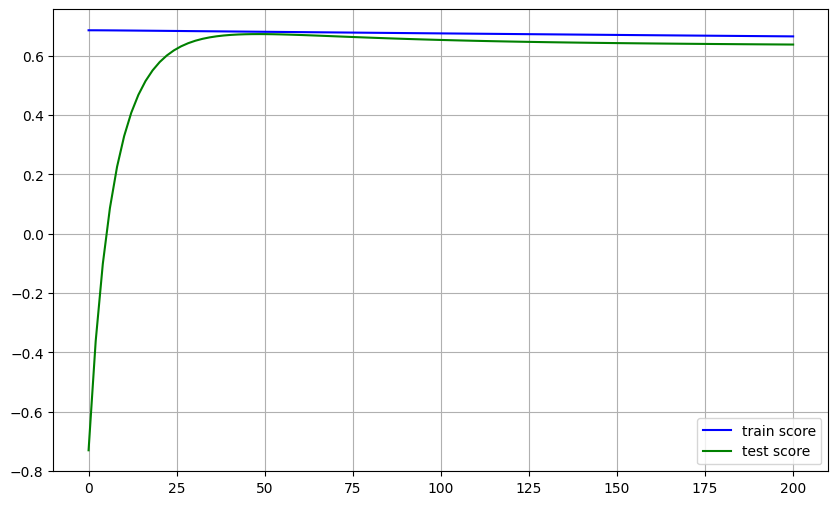

In [60]:
plot_ridge_alpha()

Отново виждаме тендецния тренировъчната оценка да намалява монотонно, а тестовата оценка първо да расте и после да намалява. Изглежда, че имаме оптимална стойност при $\alpha=50$.

In [63]:
model = Ridge(alpha=50).fit(X_train, y_train)
train_score = model.score(X_train, y_train)
test_score = model.score(X_test, y_test)

print("train:", train_score)
print("test: ", test_score)

train: 0.6808436254844323
test:  0.6729765546413613


Нека сега пробваме с `Lasso`:

In [91]:
model = Lasso().fit(X_train, y_train)

train_score = model.score(X_train, y_train)
test_score = model.score(X_test, y_test)
features_used = np.sum(model.coef_ != 0)

print("train:        ", train_score)
print("test:         ", test_score)
print("features used: {}/{}".format(features_used, len(model.coef_)))

train:         0.03338215104722497
test:          0.03387701511795971
features used: 1/44


Тотален underfit.

In [44]:
model = Lasso(alpha=0.0001).fit(X_train, y_train)

train_score = model.score(X_train, y_train)
test_score = model.score(X_test, y_test)
features_used = np.sum(model.coef_ != 0)

print("train:        ", train_score)
print("test:         ", test_score)
print("features used: {}/{}".format(features_used, len(model.coef_)))

train:         0.6858853820641364
test:          -0.4398943197743135
features used: 44/44


c:\Users\Berbatova\anaconda3\envs\ml_course\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.639e+03, tolerance: 2.066e+00
  model = cd_fast.enet_coordinate_descent(


Много силен overfit. Истината е някъде по средата.

Пак ще начертаем графика:

In [67]:
def plot_lasso_alphas():
    alphas = np.linspace(0.001, 0.1, 100)
    train_scores = []
    test_scores = []
    features_used = []
    for alpha in alphas:
        model = Lasso(alpha=alpha, random_state=0).fit(X_train, y_train)
        train_score = model.score(X_train, y_train)
        test_score = model.score(X_test, y_test)
        features = np.sum(model.coef_ != 0)

        train_scores.append(train_score)
        test_scores.append(test_score)
        features_used.append(features)

    fig, axes = plt.subplots(2, 1, figsize=(12, 10))
    axes = axes.ravel()

    axes[0].plot(alphas, train_scores, color='blue', label='train score')
    axes[0].plot(alphas, test_scores, color='green', label='test score')
    axes[0].legend()
    axes[0].grid();

    axes[1].plot(alphas, features_used, label='features used')
    axes[1].legend();
    fig.show()

c:\Users\Berbatova\anaconda3\envs\ml_course\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.550e+03, tolerance: 2.066e+00
  model = cd_fast.enet_coordinate_descent(
c:\Users\Berbatova\anaconda3\envs\ml_course\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.220e+03, tolerance: 2.066e+00
  model = cd_fast.enet_coordinate_descent(
c:\Users\Berbatova\anaconda3\envs\ml_course\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider in

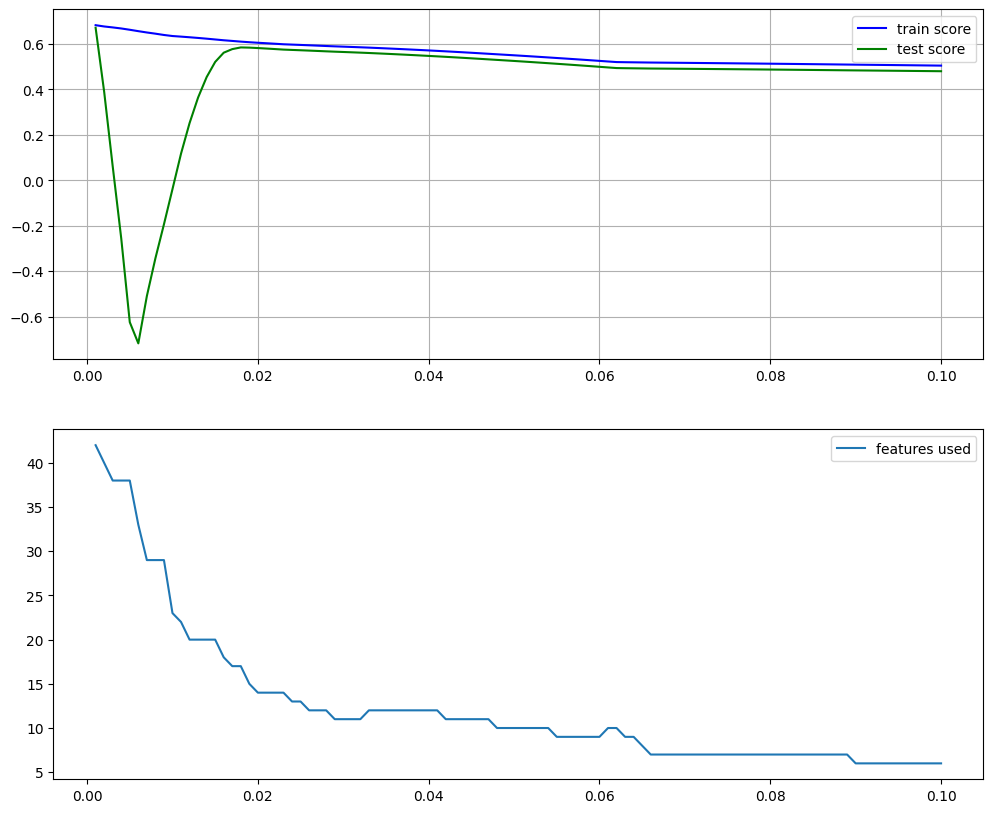

In [68]:
plot_lasso_alphas()

Виждаме, че при Lasso резултатите са доста по-ниски. 

## Размер на данните и регуларизация

Регуляризацията може да намали пренагаждането при малко данни. Ето пример:

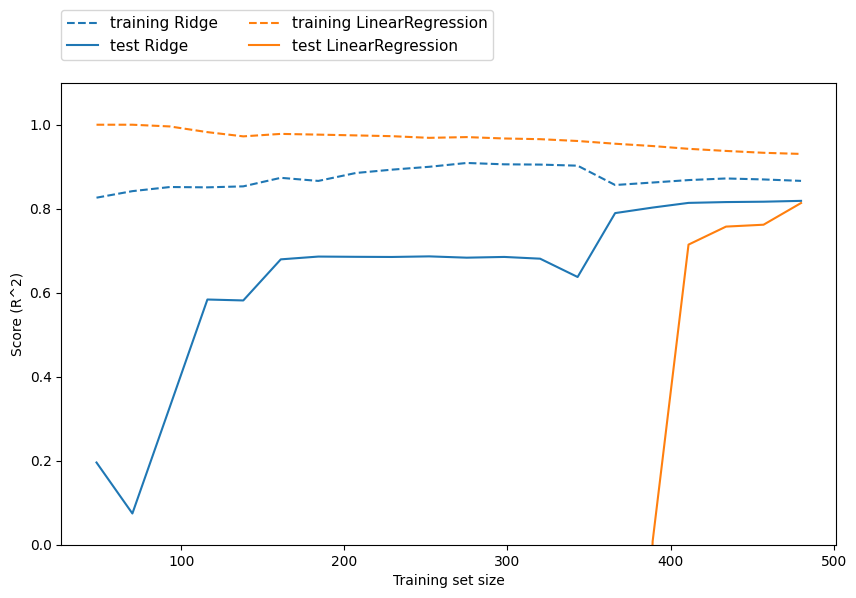

In [70]:
plt.figure(figsize=(10, 6))
mglearn.plots.plot_ridge_n_samples()

Тук се вижда, че `Ridge` се справя по-добре при по-малко тренировъчно множество. Линейната регресия без регуляризация има нужда от почти 400 точки за да научи нещо, докато `Ridge` се оправя (някак) и с по-малко.

# Избор на характеристики (feature selection) и линейна регресия

Линейната регресия може да се използва, за да ни покаже по какъв начин различните характеристики допринасят на крайния резултат. Например, може да натренираме линейна регресия за апартаментите в Калифорния и да видим как всяка характеристика допринася на цената.

Първо ще настренираме линейна регресия:

In [71]:
data = StandardScaler().fit_transform(housing.data)
X_train, X_test, y_train, y_test = train_test_split(data, housing.target)

linear = LinearRegression()
linear.fit(X_train, y_train)

print("train:", linear.score(X_train, y_train))
print("test: ", linear.score(X_test, y_test))

train: 0.6055401930401128
test:  0.6075769982744275


След това може да ползваме една библиотека, `eli5` (от Explain it Like I'm 5) за да видим стойностите на коефициентите:

In [73]:
eli5.sklearn.explain_weights.explain_linear_regressor_weights(linear, feature_names=housing.feature_names)

Weight?,Feature
+2.068,<BIAS>
+0.814,MedInc
+0.271,AveBedrms
+0.117,HouseAge
-0.004,Population
-0.040,AveOccup
-0.229,AveRooms
-0.872,Longitude
-0.905,Latitude


Може да видим че MedInc (средната заплата в региона) вдига цената на апартамента, докато Latitude (географската ширина) я сваля.

In [76]:
print(housing.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

# Обобщение

Накратко между overfit/underfit и данни, сложност и  може да се обобщи така:

|                    | по-малко | повече    |
|:-------------------|:---------|:----------|
| сложност на модела | underfit | overfit   |
| данни              | overfit  | underfit? |
| характеристики     | underfit | overfit   |

Тази таблица добре обобщава интуицията.

Струва си да се отбележи, че повече данни обикновено винаги е по-добре и не непременно ще доведе до underfit – обикновено води просто до по-добри резултати.

## Задачи

Задачи 3 и 4 от Домашно 1.

Алтернативно:
   - Изберете си едно от примерните множества данни за регресия и изследвайте как се държи при различна по вид и по степен регуларизация. Начертайте графики. 
   - Изследвайте кои са най-силно и най-слабо влияещите характеристики. 
    